# BPS5231 AI For Sustainable Building Design - L6 Simulation Game Random Forest

In [ ]:
#Import libraries and setup
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the dataset from CSV file
# your CSV file to Google Colab first using the file upload button on the left sidebar
df = pd.read_csv('/content/BPS5231-AY25_26-Sem1 - L6-Simulation Game.csv')

print("Dataset loaded from CSV!")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Display data types
print(f"\nData types:")
print(df.dtypes)

Dataset loaded from CSV!
Dataset shape: (16, 20)
Columns: ['Round', 'Team', 'Window Construction', 'Dyn_Shade', 'Lighting', 'Dimming', 'HVAC', 'Mass', 'UValue', 'WWRN', 'WWRE', 'WWRS', 'WWRW', 'ShadingN', 'ShadingE', 'ShadingS', 'ShadingW', 'EUI', 'Cost', 'KgCO2']

First few rows:
      Round  Team Window Construction Dyn_Shade Lighting Dimming  HVAC   Mass  \
0  Baseline   NaN              Single        No    Fluor      No     3  Light   
1        P1   NaN             Double1        No    Fluor      No     3  Light   
2        P2   NaN              Single        No    Fluor      No     3  Light   
3        P3   NaN              Single        No      LED     Yes     6  Light   
4        P4   NaN              Single        No    Fluor      No     3  Light   

   UValue  WWRN  WWRE  WWRS  WWRW  ShadingN  ShadingE  ShadingS  ShadingW  \
0     0.4    90    90    90    90       0.0       0.0       0.0       0.0   
1     0.4    70    70    70    70       0.0       0.0       0.0       0.0   


In [ ]:
df.head()

,Round,Team,Window Construction,Dyn_Shade,Lighting,Dimming,HVAC,Mass,UValue,WWRN,WWRE,WWRS,WWRW,ShadingN,ShadingE,ShadingS,ShadingW,EUI,Cost,KgCO2
0,Baseline,NaN,Single,No,Fluor,No,3,Light,0.4,90,90,90,90,0.0,0.0,0.0,0.0,117.0,15.6,61.3
1,P1,NaN,Double1,No,Fluor,No,3,Light,0.4,70,70,70,70,0.0,0.0,0.0,0.0,108.0,16.0,60.4
2,P2,NaN,Single,No,Fluor,No,3,Light,0.3,80,80,80,80,0.0,0.0,0.0,0.0,107.0,16.0,60.2
3,P3,NaN,Single,No,LED,Yes,6,Light,0.4,90,90,90,90,0.0,0.0,0.0,0.0,53.9,6.6,26.8
4,P4,NaN,Single,No,Fluor,No,3,Light,0.4,60,60,40,60,1.0,0.0,1.0,0.0,92.2,10.7,44.6


In [ ]:
# Cell 3: Data inspection and preparation
print("=== DATA INSPECTION ===")
print(f"Final dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Check target columns exist
target_cols = ['EUI', 'Cost', 'KgCO2']
for col in target_cols:
    if col in df.columns:
        print(f"✅ {col} column found")
    else:
        print(f"❌ {col} column missing!")

print("\nSample of complete dataset:")
display_cols = ['Round', 'Window Construction', 'HVAC', 'Lighting', 'EUI', 'Cost', 'KgCO2']
available_display_cols = [col for col in display_cols if col in df.columns]
print(df[available_display_cols].head(8))

=== DATA INSPECTION ===
Final dataset shape: (16, 20)
Columns: ['Round', 'Team', 'Window Construction', 'Dyn_Shade', 'Lighting', 'Dimming', 'HVAC', 'Mass', 'UValue', 'WWRN', 'WWRE', 'WWRS', 'WWRW', 'ShadingN', 'ShadingE', 'ShadingS', 'ShadingW', 'EUI', 'Cost', 'KgCO2']
✅ EUI column found
✅ Cost column found
✅ KgCO2 column found

Sample of complete dataset:
      Round Window Construction  HVAC Lighting    EUI  Cost  KgCO2
0  Baseline              Single     3    Fluor  117.0  15.6   61.3
1        P1             Double1     3    Fluor  108.0  16.0   60.4
2        P2              Single     3    Fluor  107.0  16.0   60.2
3        P3              Single     6      LED   53.9   6.6   26.8
4        P4              Single     3    Fluor   92.2  10.7   44.6
5        P5             Double2     3    Fluor   51.7   5.9   24.8
6        P6              Single     6    Fluor   68.0   7.6   32.1
7        P7              Triple     3      LED   85.6  12.3   46.8


In [ ]:
# Cell 4: Encode categorical variables for machine learning
def encode_features(df):
    """
    Encode categorical variables and prepare data for machine learning
    """
    # Create a copy for encoding
    df_encoded = df.copy()

    # Initialize label encoders
    encoders = {}

    # Map CSV column names to standard names for encoding
    column_mapping = {
        'Window Construction': 'Window_Construction',
        'Dyn_Shade': 'Dyn_Shade',
        'Lighting': 'Lighting',
        'Dimming': 'Dimming',
        'Mass': 'Mass'
    }

    # Find categorical columns that exist in the dataset
    categorical_cols = []
    for csv_col, standard_col in column_mapping.items():
        if csv_col in df_encoded.columns:
            categorical_cols.append(csv_col)
            # Rename column to standard name for consistency
            if csv_col != standard_col:
                df_encoded.rename(columns={csv_col: standard_col}, inplace=True)

    # Update categorical_cols to use standard names
    categorical_cols = [column_mapping[col] for col in categorical_cols]

    # Encode each categorical column
    for col in categorical_cols:
        if col in df_encoded.columns:
            encoders[col] = LabelEncoder()
            # Handle missing values
            non_null_mask = df_encoded[col].notna()
            if non_null_mask.any():
                df_encoded.loc[non_null_mask, col] = encoders[col].fit_transform(df_encoded.loc[non_null_mask, col])

    return df_encoded, encoders

df_encoded, encoders = encode_features(df)

# Show encoding mappings
print("Encoding mappings:")
for col, encoder in encoders.items():
    if hasattr(encoder, 'classes_'):
        mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
        print(f"{col}: {mapping}")

print(f"\nEncoded dataset shape: {df_encoded.shape}")
print("\nSample of encoded features:")
encoded_display_cols = ['Window_Construction', 'Dyn_Shade', 'Lighting', 'Dimming', 'HVAC', 'Mass', 'EUI']
available_encoded_cols = [col for col in encoded_display_cols if col in df_encoded.columns]
print(df_encoded[available_encoded_cols].head())

Encoding mappings:
Window_Construction: {'Double1': np.int64(0), 'Double2': np.int64(1), 'Double3': np.int64(2), 'Single': np.int64(3), 'Triple': np.int64(4)}
Dyn_Shade: {'No': np.int64(0), 'Yes': np.int64(1)}
Lighting: {'Fluor': np.int64(0), 'LED': np.int64(1)}
Dimming: {'No': np.int64(0), 'Yes': np.int64(1)}
Mass: {'Heavy': np.int64(0), 'Light': np.int64(1)}

Encoded dataset shape: (16, 20)

Sample of encoded features:
  Window_Construction Dyn_Shade Lighting Dimming  HVAC Mass    EUI
0                   3         0        0       0     3    1  117.0
1                   0         0        0       0     3    1  108.0
2                   3         0        0       0     3    1  107.0
3                   3         0        1       1     6    1   53.9
4                   3         0        0       0     3    1   92.2


In [ ]:
# Cell 5: Prepare features and targets for Random Forest training
# Define potential feature columns (adapt to CSV column names)
potential_feature_cols = [
    'Window_Construction', 'Dyn_Shade', 'Lighting', 'Dimming', 'HVAC', 'Mass', 'UValue',
    'WWRN', 'WWRE', 'WWRS', 'WWRW', 'ShadingN', 'ShadingE', 'ShadingS', 'ShadingW'
]

# Only use columns that actually exist in the dataset
feature_cols = [col for col in potential_feature_cols if col in df_encoded.columns]

# Prepare feature matrix
X = df_encoded[feature_cols]

# Handle missing values in features
X = X.fillna(X.mean(numeric_only=True)).fillna(0)  # Fill numeric NaN with mean, others with 0

# Prepare target variables
target_cols = ['EUI', 'KgCO2']
available_targets = [col for col in target_cols if col in df_encoded.columns]

if 'EUI' in df_encoded.columns:
    y_eui = df_encoded['EUI'].fillna(df_encoded['EUI'].mean())
else:
    print("⚠️  EUI column not found!")

if 'KgCO2' in df_encoded.columns:
    y_co2 = df_encoded['KgCO2'].fillna(df_encoded['KgCO2'].mean())
else:
    print("⚠️  KgCO2 column not found!")

print("Features prepared for training:")
print(f"Feature matrix shape: {X.shape}")
print(f"Available feature columns: {feature_cols}")
print(f"Available target columns: {available_targets}")

if 'EUI' in df_encoded.columns:
    print(f"EUI target shape: {y_eui.shape}, range: {y_eui.min():.1f} - {y_eui.max():.1f}")
if 'KgCO2' in df_encoded.columns:
    print(f"CO2 target shape: {y_co2.shape}, range: {y_co2.min():.1f} - {y_co2.max():.1f}")

print(f"\nFeature matrix sample:")
print(X.head())

Features prepared for training:
Feature matrix shape: (16, 15)
Available feature columns: ['Window_Construction', 'Dyn_Shade', 'Lighting', 'Dimming', 'HVAC', 'Mass', 'UValue', 'WWRN', 'WWRE', 'WWRS', 'WWRW', 'ShadingN', 'ShadingE', 'ShadingS', 'ShadingW']
Available target columns: ['EUI', 'KgCO2']
EUI target shape: (16,), range: 51.7 - 120.0
CO2 target shape: (16,), range: 24.8 - 61.3

Feature matrix sample:
   Window_Construction  Dyn_Shade  Lighting  Dimming  HVAC  Mass  UValue  \
0                    3          0         0        0     3     1     0.4   
1                    0          0         0        0     3     1     0.4   
2                    3          0         0        0     3     1     0.3   
3                    3          0         1        1     6     1     0.4   
4                    3          0         0        0     3     1     0.4   

   WWRN  WWRE  WWRS  WWRW  ShadingN  ShadingE  ShadingS  ShadingW  
0    90    90    90    90       0.0       0.0       0.0       0

/tmp/ipython-input-2076269505.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(X.mean(numeric_only=True)).fillna(0)  # Fill numeric NaN with mean, others with 0


In [ ]:
# Cell 6: Train Random Forest model for EUI prediction
if 'EUI' in df_encoded.columns:
    print("=== TRAINING RANDOM FOREST FOR EUI PREDICTION ===")

    # Split data for EUI
    X_train_eui, X_test_eui, y_train_eui, y_test_eui = train_test_split(
        X, y_eui, test_size=0.3, random_state=42
    )

    # Train Random Forest for EUI
    rf_eui = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=2
    )
    rf_eui.fit(X_train_eui, y_train_eui)

    # Make predictions
    y_pred_eui = rf_eui.predict(X_test_eui)
    y_train_pred_eui = rf_eui.predict(X_train_eui)

    # Evaluate model
    train_r2_eui = r2_score(y_train_eui, y_train_pred_eui)
    test_r2_eui = r2_score(y_test_eui, y_pred_eui)
    train_rmse_eui = np.sqrt(mean_squared_error(y_train_eui, y_train_pred_eui))
    test_rmse_eui = np.sqrt(mean_squared_error(y_test_eui, y_pred_eui))

    print(f"EUI Model Performance:")
    print(f"Training R²: {train_r2_eui:.3f}")
    print(f"Testing R²: {test_r2_eui:.3f}")
    print(f"Training RMSE: {train_rmse_eui:.2f} kWh/m²/year")
    print(f"Testing RMSE: {test_rmse_eui:.2f} kWh/m²/year")

    # Feature importance for EUI
    feature_importance_eui = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': rf_eui.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\nTop 10 Most Important Features for EUI:")
    print(feature_importance_eui.head(10))

else:
    print("⚠️  Skipping EUI model training - EUI column not available")
    rf_eui = None
    feature_importance_eui = None

=== TRAINING RANDOM FOREST FOR EUI PREDICTION ===
EUI Model Performance:
Training R²: 0.873
Testing R²: 0.044
Training RMSE: 7.67 kWh/m²/year
Testing RMSE: 28.20 kWh/m²/year

Top 10 Most Important Features for EUI:
     Feature  Importance
3    Dimming    0.428333
7       WWRN    0.265504
9       WWRS    0.109697
2   Lighting    0.050477
10      WWRW    0.039394
8       WWRE    0.021358
12  ShadingE    0.018837
14  ShadingW    0.016767
4       HVAC    0.015265
13  ShadingS    0.011578


In [ ]:
# Cell 7: Train Random Forest model for CO2 prediction
if 'KgCO2' in df_encoded.columns:
    print("=== TRAINING RANDOM FOREST FOR CO2 PREDICTION ===")

    # Split data for CO2
    X_train_co2, X_test_co2, y_train_co2, y_test_co2 = train_test_split(
        X, y_co2, test_size=0.3, random_state=42
    )

    # Train Random Forest for CO2
    rf_co2 = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=2
    )
    rf_co2.fit(X_train_co2, y_train_co2)

    # Make predictions
    y_pred_co2 = rf_co2.predict(X_test_co2)
    y_train_pred_co2 = rf_co2.predict(X_train_co2)

    # Evaluate model
    train_r2_co2 = r2_score(y_train_co2, y_train_pred_co2)
    test_r2_co2 = r2_score(y_test_co2, y_pred_co2)
    train_rmse_co2 = np.sqrt(mean_squared_error(y_train_co2, y_train_pred_co2))
    test_rmse_co2 = np.sqrt(mean_squared_error(y_test_co2, y_pred_co2))

    print(f"CO2 Model Performance:")
    print(f"Training R²: {train_r2_co2:.3f}")
    print(f"Testing R²: {test_r2_co2:.3f}")
    print(f"Training RMSE: {train_rmse_co2:.2f} kgCO2/m²/year")
    print(f"Testing RMSE: {test_rmse_co2:.2f} kgCO2/m²/year")

    # Feature importance for CO2
    feature_importance_co2 = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': rf_co2.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f"\nTop 10 Most Important Features for CO2:")
    print(feature_importance_co2.head(10))

else:
    print("⚠️  Skipping CO2 model training - KgCO2 column not available")
    rf_co2 = None
    feature_importance_co2 = None

=== TRAINING RANDOM FOREST FOR CO2 PREDICTION ===
CO2 Model Performance:
Training R²: 0.837
Testing R²: 0.111
Training RMSE: 4.33 kgCO2/m²/year
Testing RMSE: 15.74 kgCO2/m²/year

Top 10 Most Important Features for CO2:
                Feature  Importance
3               Dimming    0.486501
9                  WWRS    0.185460
7                  WWRN    0.155363
2              Lighting    0.038528
12             ShadingE    0.027070
6                UValue    0.022663
14             ShadingW    0.021494
10                 WWRW    0.016601
0   Window_Construction    0.011825
11             ShadingN    0.011746


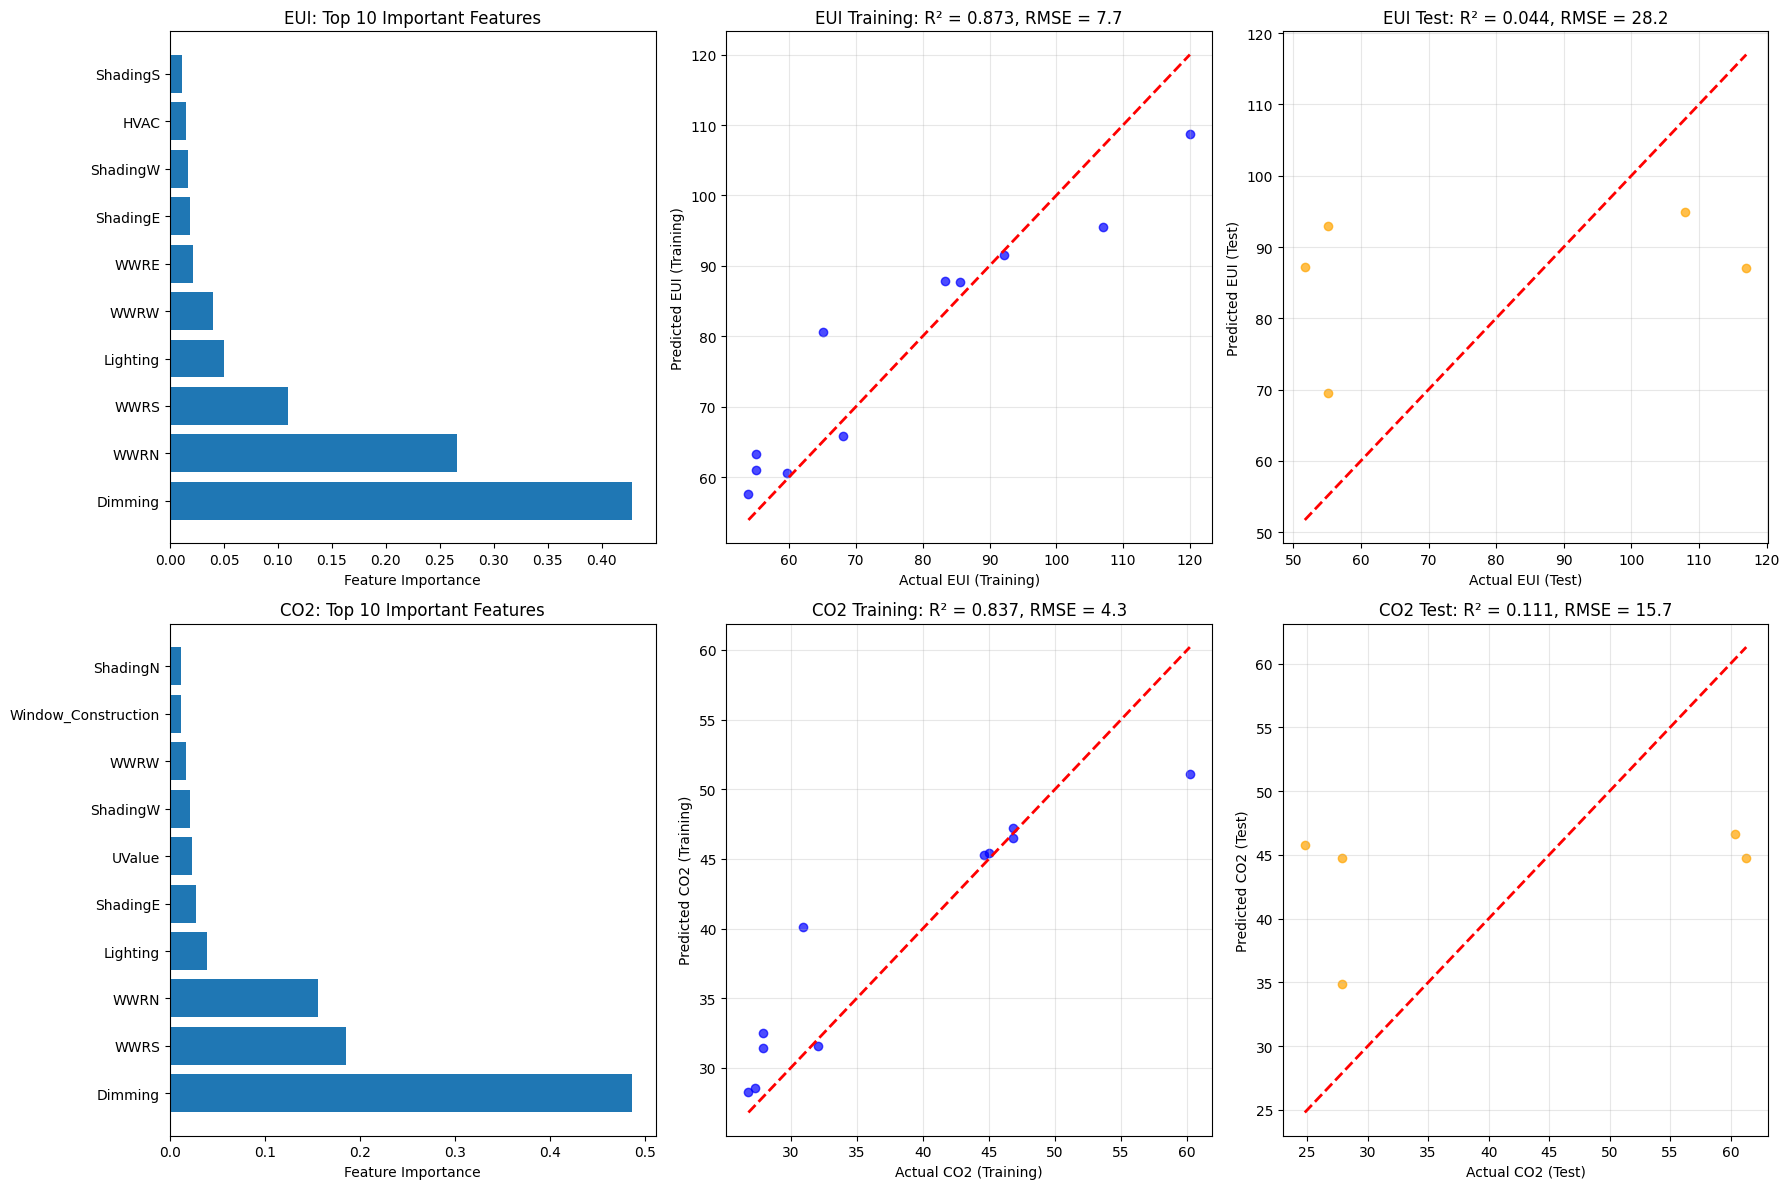


=== MODEL PERFORMANCE SUMMARY ===
EUI Model:
  Training R²: 0.873 | Test R²: 0.044
  Training RMSE: 7.7 | Test RMSE: 28.2
  ⚠️  Potential overfitting detected (Train-Test R² gap: 0.829)

CO2 Model:
  Training R²: 0.837 | Test R²: 0.111
  Training RMSE: 4.3 | Test RMSE: 15.7
  ⚠️  Potential overfitting detected (Train-Test R² gap: 0.727)

💡 Teaching Points:
   • Training R² should be higher than Test R² (model memorizes training data)
   • Large gap suggests overfitting (model doesn't generalize well)
   • Points near diagonal line = good predictions
   • Scattered points = poor model performance


In [ ]:
# Cell 8: Visualizations and model comparison - Training and Test Performance
# Determine what plots to create based on available models
plots_to_create = []
if rf_eui is not None:
    plots_to_create.append('eui')
if rf_co2 is not None:
    plots_to_create.append('co2')

if not plots_to_create:
    print("⚠️  No models available for visualization")
else:
    # Calculate figure layout - 3 plots per model (feature importance + train + test)
    n_cols = 3
    n_rows = len(plots_to_create)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))

    # Ensure axes is 2D array even with single row
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    plot_row = 0

    # EUI plots
    if 'eui' in plots_to_create:
        # Feature importance
        top_features = min(10, len(feature_importance_eui))
        axes[plot_row, 0].barh(feature_importance_eui.head(top_features)['Feature'],
                              feature_importance_eui.head(top_features)['Importance'])
        axes[plot_row, 0].set_title(f'EUI: Top {top_features} Important Features')
        axes[plot_row, 0].set_xlabel('Feature Importance')

        # Training predictions vs actual
        axes[plot_row, 1].scatter(y_train_eui, y_train_pred_eui, alpha=0.7, color='blue', label='Training')
        axes[plot_row, 1].plot([y_train_eui.min(), y_train_eui.max()],
                              [y_train_eui.min(), y_train_eui.max()], 'r--', lw=2)
        axes[plot_row, 1].set_xlabel('Actual EUI (Training)')
        axes[plot_row, 1].set_ylabel('Predicted EUI (Training)')
        axes[plot_row, 1].set_title(f'EUI Training: R² = {train_r2_eui:.3f}, RMSE = {train_rmse_eui:.1f}')
        axes[plot_row, 1].grid(True, alpha=0.3)

        # Test predictions vs actual
        axes[plot_row, 2].scatter(y_test_eui, y_pred_eui, alpha=0.7, color='orange', label='Test')
        axes[plot_row, 2].plot([y_test_eui.min(), y_test_eui.max()],
                              [y_test_eui.min(), y_test_eui.max()], 'r--', lw=2)
        axes[plot_row, 2].set_xlabel('Actual EUI (Test)')
        axes[plot_row, 2].set_ylabel('Predicted EUI (Test)')
        axes[plot_row, 2].set_title(f'EUI Test: R² = {test_r2_eui:.3f}, RMSE = {test_rmse_eui:.1f}')
        axes[plot_row, 2].grid(True, alpha=0.3)

        plot_row += 1

    # CO2 plots
    if 'co2' in plots_to_create:
        # Feature importance
        top_features = min(10, len(feature_importance_co2))
        axes[plot_row, 0].barh(feature_importance_co2.head(top_features)['Feature'],
                              feature_importance_co2.head(top_features)['Importance'])
        axes[plot_row, 0].set_title(f'CO2: Top {top_features} Important Features')
        axes[plot_row, 0].set_xlabel('Feature Importance')

        # Training predictions vs actual
        axes[plot_row, 1].scatter(y_train_co2, y_train_pred_co2, alpha=0.7, color='blue', label='Training')
        axes[plot_row, 1].plot([y_train_co2.min(), y_train_co2.max()],
                              [y_train_co2.min(), y_train_co2.max()], 'r--', lw=2)
        axes[plot_row, 1].set_xlabel('Actual CO2 (Training)')
        axes[plot_row, 1].set_ylabel('Predicted CO2 (Training)')
        axes[plot_row, 1].set_title(f'CO2 Training: R² = {train_r2_co2:.3f}, RMSE = {train_rmse_co2:.1f}')
        axes[plot_row, 1].grid(True, alpha=0.3)

        # Test predictions vs actual
        axes[plot_row, 2].scatter(y_test_co2, y_pred_co2, alpha=0.7, color='orange', label='Test')
        axes[plot_row, 2].plot([y_test_co2.min(), y_test_co2.max()],
                              [y_test_co2.min(), y_test_co2.max()], 'r--', lw=2)
        axes[plot_row, 2].set_xlabel('Actual CO2 (Test)')
        axes[plot_row, 2].set_ylabel('Predicted CO2 (Test)')
        axes[plot_row, 2].set_title(f'CO2 Test: R² = {test_r2_co2:.3f}, RMSE = {test_rmse_co2:.1f}')
        axes[plot_row, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary comparison
    print("\n=== MODEL PERFORMANCE SUMMARY ===")
    if rf_eui is not None:
        print(f"EUI Model:")
        print(f"  Training R²: {train_r2_eui:.3f} | Test R²: {test_r2_eui:.3f}")
        print(f"  Training RMSE: {train_rmse_eui:.1f} | Test RMSE: {test_rmse_eui:.1f}")

        # Check for overfitting
        if train_r2_eui - test_r2_eui > 0.2:
            print(f"  ⚠️  Potential overfitting detected (Train-Test R² gap: {train_r2_eui - test_r2_eui:.3f})")
        else:
            print(f"  ✅ Good generalization (Train-Test R² gap: {train_r2_eui - test_r2_eui:.3f})")

    if rf_co2 is not None:
        print(f"\nCO2 Model:")
        print(f"  Training R²: {train_r2_co2:.3f} | Test R²: {test_r2_co2:.3f}")
        print(f"  Training RMSE: {train_rmse_co2:.1f} | Test RMSE: {test_rmse_co2:.1f}")

        # Check for overfitting
        if train_r2_co2 - test_r2_co2 > 0.2:
            print(f"  ⚠️  Potential overfitting detected (Train-Test R² gap: {train_r2_co2 - test_r2_co2:.3f})")
        else:
            print(f"  ✅ Good generalization (Train-Test R² gap: {train_r2_co2 - test_r2_co2:.3f})")

    print(f"\n💡 Teaching Points:")
    print(f"   • Training R² should be higher than Test R² (model memorizes training data)")
    print(f"   • Large gap suggests overfitting (model doesn't generalize well)")
    print(f"   • Points near diagonal line = good predictions")
    print(f"   • Scattered points = poor model performance")

In [ ]:
# Cell 9: Interactive prediction - What-if analysis
def predict_performance(window_type, dyn_shade, lighting, dimming, hvac, mass, u_value,
                       wwrn, wwre, wwrs, wwrw, shade_n, shade_e, shade_s, shade_w):
    """
    Predict EUI and CO2 for a custom building configuration
    """
    if rf_eui is None and rf_co2 is None:
        print("⚠️  No trained models available for prediction")
        return None, None

    # Create input array with standard column names
    input_data = pd.DataFrame({
        'Window_Construction': [window_type],
        'Dyn_Shade': [dyn_shade],
        'Lighting': [lighting],
        'Dimming': [dimming],
        'HVAC': [hvac],
        'Mass': [mass],
        'UValue': [u_value],
        'WWRN': [wwrn], 'WWRE': [wwre], 'WWRS': [wwrs], 'WWRW': [wwrw],
        'ShadingN': [shade_n], 'ShadingE': [shade_e], 'ShadingS': [shade_s], 'ShadingW': [shade_w]
    })

    # Encode categorical variables using the same encoders
    for col in ['Window_Construction', 'Dyn_Shade', 'Lighting', 'Dimming', 'Mass']:
        if col in encoders and col in input_data.columns:
            try:
                input_data[col] = encoders[col].transform(input_data[col])
            except ValueError as e:
                print(f"⚠️  Warning: {col} value '{input_data[col].iloc[0]}' not seen in training data")
                # Use the first class as default
                input_data[col] = 0

    # Select only features that were used in training
    input_features = input_data[feature_cols]

    # Make predictions
    predicted_eui = rf_eui.predict(input_features)[0] if rf_eui is not None else None
    predicted_co2 = rf_co2.predict(input_features)[0] if rf_co2 is not None else None

    return predicted_eui, predicted_co2

# Example predictions - Find baseline values from data
baseline_idx = 0  # Assume first row is baseline
baseline_data = df.iloc[baseline_idx]

print("=== WHAT-IF ANALYSIS ===")
print("Baseline building performance:")

# Use actual baseline values from the dataset
baseline_eui, baseline_co2 = predict_performance(
    baseline_data.get('Window Construction', 'Single'),
    baseline_data.get('Dyn_Shade', 'No'),
    baseline_data.get('Lighting', 'Fluor'),
    baseline_data.get('Dimming', 'No'),
    baseline_data.get('HVAC', 3),
    baseline_data.get('Mass', 'Light'),
    baseline_data.get('UValue', 0.4),
    baseline_data.get('WWRN', 90), baseline_data.get('WWRE', 90),
    baseline_data.get('WWRS', 90), baseline_data.get('WWRW', 90),
    baseline_data.get('ShadingN', 0), baseline_data.get('ShadingE', 0),
    baseline_data.get('ShadingS', 0), baseline_data.get('ShadingW', 0)
)

if baseline_eui is not None:
    print(f"Baseline EUI: {baseline_eui:.1f} kWh/m²/year")
if baseline_co2 is not None:
    print(f"Baseline CO2: {baseline_co2:.1f} kgCO2/m²/year")

print("\nWhat if we upgrade to LED + Dimming + Better HVAC?")
improved_eui, improved_co2 = predict_performance('Single', 'No', 'LED', 'Yes', 6, 'Light', 0.4,
                                                90, 90, 90, 90, 0, 0, 0, 0)

if improved_eui is not None and baseline_eui is not None:
    print(f"Improved EUI: {improved_eui:.1f} kWh/m²/year ({(baseline_eui-improved_eui)/baseline_eui*100:.1f}% improvement)")
if improved_co2 is not None and baseline_co2 is not None:
    print(f"Improved CO2: {improved_co2:.1f} kgCO2/m²/year ({(baseline_co2-improved_co2)/baseline_co2*100:.1f}% improvement)")

print("\nWhat if we also reduce WWR and add triple glazing?")
optimized_eui, optimized_co2 = predict_performance('Triple', 'No', 'LED', 'Yes', 6, 'Heavy', 0.1,
                                                  30, 30, 30, 30, 1, 1, 1, 1)

if optimized_eui is not None and baseline_eui is not None:
    print(f"Optimized EUI: {optimized_eui:.1f} kWh/m²/year ({(baseline_eui-optimized_eui)/baseline_eui*100:.1f}% improvement)")
if optimized_co2 is not None and baseline_co2 is not None:
    print(f"Optimized CO2: {optimized_co2:.1f} kgCO2/m²/year ({(baseline_co2-optimized_co2)/baseline_co2*100:.1f}% improvement)")


=== WHAT-IF ANALYSIS ===
Baseline building performance:
Baseline EUI: 87.0 kWh/m²/year
Baseline CO2: 44.8 kgCO2/m²/year

What if we upgrade to LED + Dimming + Better HVAC?
Improved EUI: 57.6 kWh/m²/year (33.9% improvement)
Improved CO2: 28.3 kgCO2/m²/year (36.8% improvement)

What if we also reduce WWR and add triple glazing?
Optimized EUI: 65.7 kWh/m²/year (24.6% improvement)
Optimized CO2: 33.1 kgCO2/m²/year (26.1% improvement)


In [ ]:
# Cell 10: Student exercise - Find optimal building design
print("=== STUDENT EXERCISE: OPTIMIZATION CHALLENGE ===")

if rf_eui is not None or rf_co2 is not None:
    print("Try to find the building configuration with the lowest EUI and CO2!")
    print("Modify the parameters below and see how the predictions change:")

    # Students can modify these parameters
    student_config = {
        'window_type': 'Triple',      # Options: Single, Double1, Double2, Double3, Triple
        'dyn_shade': 'Yes',           # Options: No, Yes
        'lighting': 'LED',            # Options: Fluor, LED
        'dimming': 'Yes',             # Options: No, Yes
        'hvac': 6,                    # Options: 3, 6
        'mass': 'Heavy',              # Options: Light, Heavy
        'u_value': 0.1,               # Options: 0.1, 0.2, 0.3, 0.4
        'wwrn': 20, 'wwre': 15, 'wwrs': 10, 'wwrw': 25,  # Range: 10-90
        'shade_n': 1.5, 'shade_e': 2.0, 'shade_s': 2.0, 'shade_w': 1.5   # Range: 0-2
    }

    student_eui, student_co2 = predict_performance(**student_config)

    print(f"\nYour optimized design:")
    if student_eui is not None:
        print(f"EUI: {student_eui:.1f} kWh/m²/year")
    if student_co2 is not None:
        print(f"CO2: {student_co2:.1f} kgCO2/m²/year")

    if baseline_eui is not None and student_eui is not None:
        improvement_eui = (baseline_eui-student_eui)/baseline_eui*100
        print(f"EUI improvement from baseline: {improvement_eui:.1f}%")
    if baseline_co2 is not None and student_co2 is not None:
        improvement_co2 = (baseline_co2-student_co2)/baseline_co2*100
        print(f"CO2 improvement from baseline: {improvement_co2:.1f}%")

else:
    print("⚠️  No trained models available for optimization exercise")

print("\n=== SURROGATE MODEL TRAINING COMPLETE ===")
print("Key Learnings:")
print("1. Random Forest can learn complex relationships between building parameters")
print("2. Feature importance shows which parameters matter most")
print("3. Model enables rapid 'what-if' analysis without running simulations")
print("4. With more data points, model accuracy would improve significantly")

# Summary of available models
print(f"\n=== MODEL AVAILABILITY SUMMARY ===")
print(f"EUI Model: {'✅ Trained' if rf_eui is not None else '❌ Not available'}")
print(f"CO2 Model: {'✅ Trained' if rf_co2 is not None else '❌ Not available'}")
print(f"Features used: {len(feature_cols)} ({', '.join(feature_cols[:5])}...)")
print(f"Training data points: {len(df)}")

if rf_eui is not None:
    print(f"EUI Model R²: {test_r2_eui:.3f}")
if rf_co2 is not None:
    print(f"CO2 Model R²: {test_r2_co2:.3f}")

=== STUDENT EXERCISE: OPTIMIZATION CHALLENGE ===
Try to find the building configuration with the lowest EUI and CO2!
Modify the parameters below and see how the predictions change:

Your optimized design:
EUI: 80.2 kWh/m²/year
CO2: 33.1 kgCO2/m²/year
EUI improvement from baseline: 7.9%
CO2 improvement from baseline: 26.0%

=== SURROGATE MODEL TRAINING COMPLETE ===
Key Learnings:
1. Random Forest can learn complex relationships between building parameters
2. Feature importance shows which parameters matter most
3. Model enables rapid 'what-if' analysis without running simulations
4. With more data points, model accuracy would improve significantly

=== MODEL AVAILABILITY SUMMARY ===
EUI Model: ✅ Trained
CO2 Model: ✅ Trained
Features used: 15 (Window_Construction, Dyn_Shade, Lighting, Dimming, HVAC...)
Training data points: 16
EUI Model R²: 0.044
CO2 Model R²: 0.111


In [ ]:
import warnings
import os
import logging

# Suppress all Python warnings
warnings.filterwarnings('ignore')

# Suppress specific warning categories
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=PendingDeprecationWarning)
warnings.filterwarnings('ignore', category=ImportWarning)

# Suppress library-specific warnings
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # TensorFlow
os.environ['CUDA_VISIBLE_DEVICES'] = ''   # CUDA warnings

# Logging configuration
logging.getLogger().setLevel(logging.ERROR)
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('PIL').setLevel(logging.ERROR)
logging.getLogger('sklearn').setLevel(logging.ERROR)

# Additional suppression for Jupyter/Colab
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")

print("🔇 All warnings suppressed successfully!")
print("📝 Note: This hides all warning messages including important ones")
print("🔧 Remove this cell if you need to debug issues")

🔇 All warnings suppressed successfully!
📝 Note: This hides all warning messages including important ones
🔧 Remove this cell if you need to debug issues


In [ ]:
# Cell 11: Interactive Surrogate Model Demo - Student Playground
# Install ipywidgets if not already installed
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
except ImportError:
    !pip install ipywidgets
    import ipywidgets as widgets
    from IPython.display import display, clear_output

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

def create_interactive_building_optimizer():
    """
    Create an interactive interface for students to explore building optimization
    """
    if rf_eui is None:
        print("⚠️  EUI model not available. Cannot create interactive demo.")
        return

    # Create output widget for displaying results
    output = widgets.Output()

    # Define widget styles
    style = {'description_width': '140px'}
    layout = widgets.Layout(width='300px')

    # Create interactive widgets
    window_widget = widgets.Dropdown(
        options=['Single', 'Double1', 'Double2', 'Double3', 'Triple'],
        value='Single',
        description='Window Type:',
        style=style,
        layout=layout
    )

    dyn_shade_widget = widgets.Dropdown(
        options=['No', 'Yes'],
        value='No',
        description='Dynamic Shading:',
        style=style,
        layout=layout
    )

    lighting_widget = widgets.Dropdown(
        options=['Fluor', 'LED'],
        value='Fluor',
        description='Lighting:',
        style=style,
        layout=layout
    )

    dimming_widget = widgets.Dropdown(
        options=['No', 'Yes'],
        value='No',
        description='Dimming Controls:',
        style=style,
        layout=layout
    )

    hvac_widget = widgets.Dropdown(
        options=[3, 6],
        value=3,
        description='HVAC COP:',
        style=style,
        layout=layout
    )

    mass_widget = widgets.Dropdown(
        options=['Light', 'Heavy'],
        value='Light',
        description='Thermal Mass:',
        style=style,
        layout=layout
    )

    uvalue_widget = widgets.Dropdown(
        options=[0.4, 0.3, 0.2, 0.1],
        value=0.4,
        description='U-Value:',
        style=style,
        layout=layout
    )

    # WWR sliders
    wwrn_widget = widgets.IntSlider(
        min=10, max=90, step=5, value=90,
        description='WWR North (%):',
        style=style,
        layout=layout
    )

    wwre_widget = widgets.IntSlider(
        min=10, max=90, step=5, value=90,
        description='WWR East (%):',
        style=style,
        layout=layout
    )

    wwrs_widget = widgets.IntSlider(
        min=10, max=90, step=5, value=90,
        description='WWR South (%):',
        style=style,
        layout=layout
    )

    wwrw_widget = widgets.IntSlider(
        min=10, max=90, step=5, value=90,
        description='WWR West (%):',
        style=style,
        layout=layout
    )

    # Shading sliders
    shade_n_widget = widgets.FloatSlider(
        min=0, max=2, step=0.1, value=0,
        description='North Shading (m):',
        style=style,
        layout=layout
    )

    shade_e_widget = widgets.FloatSlider(
        min=0, max=2, step=0.1, value=0,
        description='East Shading (m):',
        style=style,
        layout=layout
    )

    shade_s_widget = widgets.FloatSlider(
        min=0, max=2, step=0.1, value=0,
        description='South Shading (m):',
        style=style,
        layout=layout
    )

    shade_w_widget = widgets.FloatSlider(
        min=0, max=2, step=0.1, value=0,
        description='West Shading (m):',
        style=style,
        layout=layout
    )

    # Reset button
    reset_button = widgets.Button(
        description="Reset to Baseline (Worst Case)",
        button_style='warning',
        layout=widgets.Layout(width='250px')
    )

    optimize_button = widgets.Button(
        description="Auto-Optimize (Best Case)",
        button_style='success',
        layout=widgets.Layout(width='250px')
    )

    def reset_to_baseline(b):
        """Reset all parameters to worst-case baseline"""
        window_widget.value = 'Single'
        dyn_shade_widget.value = 'No'
        lighting_widget.value = 'Fluor'
        dimming_widget.value = 'No'
        hvac_widget.value = 3
        mass_widget.value = 'Light'
        uvalue_widget.value = 0.4
        wwrn_widget.value = 90
        wwre_widget.value = 90
        wwrs_widget.value = 90
        wwrw_widget.value = 90
        shade_n_widget.value = 0
        shade_e_widget.value = 0
        shade_s_widget.value = 0
        shade_w_widget.value = 0

    def auto_optimize(b):
        """Set all parameters to best-case scenario"""
        window_widget.value = 'Triple'
        dyn_shade_widget.value = 'Yes'
        lighting_widget.value = 'LED'
        dimming_widget.value = 'Yes'
        hvac_widget.value = 6
        mass_widget.value = 'Heavy'
        uvalue_widget.value = 0.1
        wwrn_widget.value = 30
        wwre_widget.value = 20
        wwrs_widget.value = 15
        wwrw_widget.value = 25
        shade_n_widget.value = 1.0
        shade_e_widget.value = 1.5
        shade_s_widget.value = 2.0
        shade_w_widget.value = 1.5

    reset_button.on_click(reset_to_baseline)
    optimize_button.on_click(auto_optimize)

    def update_prediction(*args):
        """Update the prediction and visualization when parameters change"""
        with output:
            clear_output(wait=True)

            # Get current values
            current_eui, current_co2 = predict_performance(
                window_widget.value,
                dyn_shade_widget.value,
                lighting_widget.value,
                dimming_widget.value,
                hvac_widget.value,
                mass_widget.value,
                uvalue_widget.value,
                wwrn_widget.value,
                wwre_widget.value,
                wwrs_widget.value,
                wwrw_widget.value,
                shade_n_widget.value,
                shade_e_widget.value,
                shade_s_widget.value,
                shade_w_widget.value
            )

            if current_eui is None:
                print("⚠️  Cannot make prediction")
                return

            # Calculate baseline for comparison
            baseline_eui, baseline_co2 = predict_performance(
                'Single', 'No', 'Fluor', 'No', 3, 'Light', 0.4,
                90, 90, 90, 90, 0, 0, 0, 0
            )

            # Create visualization
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

            # 1. EUI Comparison Bar Chart
            categories = ['Baseline\n(Worst)', 'Your Design']
            eui_values = [baseline_eui, current_eui]
            colors = ['red', 'green' if current_eui < baseline_eui else 'orange']

            bars1 = ax1.bar(categories, eui_values, color=colors, alpha=0.7, edgecolor='black')
            ax1.set_ylabel('EUI (kWh/m²/year)')
            ax1.set_title('Energy Use Intensity Comparison')
            ax1.grid(True, alpha=0.3)

            # Add value labels on bars
            for bar, value in zip(bars1, eui_values):
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        f'{value:.0f}', ha='center', va='bottom', fontweight='bold')

            # 2. Building Visualization (WWR representation)
            ax2.set_xlim(0, 10)
            ax2.set_ylim(0, 8)

            # Draw building outline
            building = Rectangle((2, 1), 6, 6, fill=False, edgecolor='black', linewidth=3)
            ax2.add_patch(building)

            # Draw windows based on WWR (simplified)
            facades = {
                'North': (wwrn_widget.value, 2, 7, 6, 1),  # x, y, width, height, orientation
                'South': (wwrs_widget.value, 2, 1, 6, 1),
                'East': (wwre_widget.value, 8, 2, 1, 5),
                'West': (wwrw_widget.value, 2, 2, 1, 5)
            }

            for facade, (wwr, x, y, w, h) in facades.items():
                window_area = wwr / 100
                if facade in ['North', 'South']:
                    window_width = w * window_area
                    window_x = x + (w - window_width) / 2
                    window = Rectangle((window_x, y), window_width, h,
                                     fill=True, facecolor='lightblue', edgecolor='blue', alpha=0.6)
                else:
                    window_height = h * window_area
                    window_y = y + (h - window_height) / 2
                    window = Rectangle((x, window_y), w, window_height,
                                     fill=True, facecolor='lightblue', edgecolor='blue', alpha=0.6)
                ax2.add_patch(window)

            # Add shading representation
            shade_colors = ['gray', 'darkgray']
            if shade_n_widget.value > 0:
                shade = Rectangle((2, 7), 6, shade_n_widget.value/2, fill=True,
                                facecolor=shade_colors[0], alpha=0.5)
                ax2.add_patch(shade)

            ax2.set_aspect('equal')
            ax2.set_title('Building Configuration Visualization')
            ax2.set_xlabel('(Blue = Windows, Gray = Shading)')
            ax2.axis('off')

            # 3. Performance Metrics
            if baseline_eui and current_eui:
                improvement = ((baseline_eui - current_eui) / baseline_eui) * 100

                metrics_text = f"""
🏠 CURRENT BUILDING PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 EUI: {current_eui:.1f} kWh/m²/year
📈 Improvement: {improvement:.1f}%
🎯 Status: {'✅ BETTER' if improvement > 0 else '❌ WORSE'} than baseline

🔧 CURRENT CONFIGURATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🪟 Windows: {window_widget.value}
☀️ Dynamic Shading: {dyn_shade_widget.value}
💡 Lighting: {lighting_widget.value} + Dimming: {dimming_widget.value}
🌡️ HVAC COP: {hvac_widget.value}
🧱 Thermal Mass: {mass_widget.value}
🏠 U-Value: {uvalue_widget.value}

📐 WINDOW-TO-WALL RATIOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
North: {wwrn_widget.value}%  |  East: {wwre_widget.value}%
South: {wwrs_widget.value}%  |  West: {wwrw_widget.value}%

☂️ SHADING DEPTHS (meters)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
North: {shade_n_widget.value:.1f}m  |  East: {shade_e_widget.value:.1f}m
South: {shade_s_widget.value:.1f}m  |  West: {shade_w_widget.value:.1f}m
                """

                ax3.text(0.05, 0.95, metrics_text, transform=ax3.transAxes, fontsize=10,
                        verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
                ax3.axis('off')

            # 4. Parameter Impact Analysis (Feature Importance visualization)
            if 'feature_importance_eui' in globals() and feature_importance_eui is not None:
                top_features = feature_importance_eui.head(8)
                ax4.barh(range(len(top_features)), top_features['Importance'], color='steelblue', alpha=0.7)
                ax4.set_yticks(range(len(top_features)))
                ax4.set_yticklabels(top_features['Feature'])
                ax4.set_xlabel('Feature Importance')
                ax4.set_title('Which Parameters Matter Most?')
                ax4.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

            # Additional educational insights
            print("🎓 LEARNING INSIGHTS:")
            print("━━━━━━━━━━━━━━━━━━━")
            if improvement > 20:
                print("🌟 Excellent optimization! You've made significant improvements.")
            elif improvement > 10:
                print("👍 Good job! Solid energy savings achieved.")
            elif improvement > 0:
                print("📈 On the right track. Try more aggressive parameters for bigger savings.")
            else:
                print("⚠️ This configuration performs worse than baseline. Try the 'Auto-Optimize' button!")

            print(f"\n💡 Try changing the parameters with highest 'Feature Importance' for maximum impact!")

    # Connect all widgets to the update function
    all_widgets = [
        window_widget, dyn_shade_widget, lighting_widget, dimming_widget,
        hvac_widget, mass_widget, uvalue_widget,
        wwrn_widget, wwre_widget, wwrs_widget, wwrw_widget,
        shade_n_widget, shade_e_widget, shade_s_widget, shade_w_widget
    ]

    for widget in all_widgets:
        widget.observe(update_prediction, names='value')

    # Create the interface layout
    print("🎮 INTERACTIVE BUILDING ENERGY OPTIMIZER")
    print("=" * 50)
    print("Adjust the parameters below and watch the EUI prediction change in real-time!")
    print("Use this tool to understand which building parameters have the biggest impact on energy performance.")

    # Layout widgets in organized groups
    building_systems = widgets.VBox([
        widgets.HTML("<b>🏠 Building Systems</b>"),
        widgets.HBox([window_widget, dyn_shade_widget]),
        widgets.HBox([lighting_widget, dimming_widget]),
        widgets.HBox([hvac_widget, mass_widget, uvalue_widget])
    ])

    facade_design = widgets.VBox([
        widgets.HTML("<b>🪟 Facade Design</b>"),
        widgets.HTML("<i>Window-to-Wall Ratios (%)</i>"),
        widgets.HBox([wwrn_widget, wwre_widget]),
        widgets.HBox([wwrs_widget, wwrw_widget]),
        widgets.HTML("<i>Shading Depths (meters)</i>"),
        widgets.HBox([shade_n_widget, shade_e_widget]),
        widgets.HBox([shade_s_widget, shade_w_widget])
    ])

    control_buttons = widgets.HBox([reset_button, optimize_button])

    # Display everything
    display(widgets.VBox([
        control_buttons,
        widgets.HBox([building_systems, facade_design]),
        output
    ]))

    # Initial prediction
    update_prediction()

# Execute the interactive demo
if 'rf_eui' in globals() and rf_eui is not None:
    print("🚀 Creating Interactive Building Optimizer...")
    create_interactive_building_optimizer()
else:
    print("⚠️  Interactive demo requires EUI model to be trained first!")
    print("Please run the previous cells to train the Random Forest model.")

🚀 Creating Interactive Building Optimizer...
🎮 INTERACTIVE BUILDING ENERGY OPTIMIZER
Adjust the parameters below and watch the EUI prediction change in real-time!
Use this tool to understand which building parameters have the biggest impact on energy performance.
